In [3]:
import re
import numpy as np
import matplotlib.pyplot as plt 

def parse_matrix_file(path):
    """Parse a file written by print_matrix_to_file -> (label, np.ndarray of shape (rows, cols))."""
    text = open(path).read()

    # split "label = [ ... ]"
    m = re.search(r"(\w+)\s*=\s*\[(.*)\]", text, re.DOTALL)
    assert m, f"no 'label = [...]' found in {path}"
    label, body = m.group(1), m.group(2)

    # each inner [ ... ] is a row
    rows = re.findall(r"\[([^\[\]]*)\]", body)
    data = [[float(v) for v in r.split(",") if v.strip()] for r in rows]

    return label, np.array(data)

In [78]:
l, data = parse_matrix_file("compl_gradient_output.txt")
# data = data[120]
data = data.reshape(-1)
data.shape

(533520,)

In [80]:
neg = np.abs(data[data < 0])
pos = np.abs(data[data > 0])

def get_lims(arr):
    n = arr.shape[0]
    m = np.sort(arr)[int(n * 0.95)]
    a = arr[arr < m]
    a = np.pow(a, 0.5)
    return [0.0, a.max().item()]

def compact(arr):
    n = arr.shape[0]
    m = np.sort(arr)[int(n * 0.95)]
    a = arr[arr < m]
    a = np.pow(a, 0.5)
    return a

get_lims(neg)

[0.0, 1.2118250698842634]

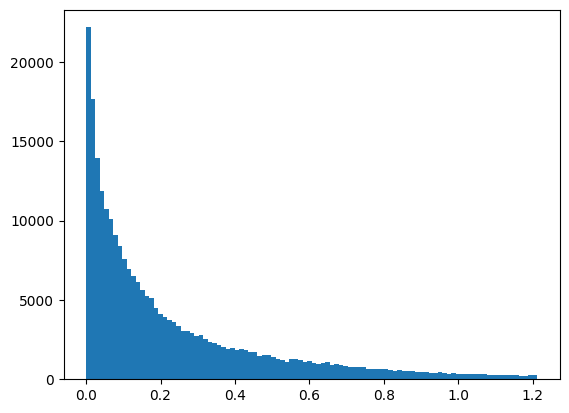

In [83]:
plt.hist(compact(neg), bins=100)
plt.show()

In [82]:
np.sum(data<0.0) / np.sum(data>0.0)

np.float64(1.0043782537868289)

In [38]:
pow(0.00000000001, 0.1)

0.07943282347242814